# 04 - Model Training (Decision Tree)

In this notebook, we train a Decision Tree classifier to predict whether a star hosts a gas giant planet based on stellar properties.

In [2]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/exoplanets_clean.csv")

df.head()

,pl_name,discoverymethod,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,...,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,sy_dist,sy_disterr1,sy_disterr2
0,11 Com b,Radial Velocity,323.21000,0.06,-0.05,0.0,NaN,NaN,NaN,NaN,...,0.08,-0.08,0.0,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
1,11 Com b,Radial Velocity,326.03000,0.32,-0.32,0.0,NaN,NaN,NaN,NaN,...,0.10,-0.10,0.0,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
2,11 Com b,Radial Velocity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
3,11 UMi b,Radial Velocity,516.21997,3.20,-3.20,0.0,NaN,NaN,NaN,NaN,...,0.07,-0.07,0.0,NaN,NaN,NaN,NaN,125.3210,1.9765,-1.9765
4,11 UMi b,Radial Velocity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.3210,1.9765,-1.9765


In [3]:
df = df.dropna(subset=["pl_rade"])

df["is_gas_giant"] = (df["pl_rade"] > 6).astype(int)

In [4]:
features = ["st_teff", "st_rad", "st_met", "st_age"]

df_ml = df[features + ["is_gas_giant"]].dropna()

X = df_ml[features]
y = df_ml["is_gas_giant"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("🌳 Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

🌳 Decision Tree Accuracy: 0.7862660944206008
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       877
           1       0.67      0.27      0.38       288

    accuracy                           0.79      1165
   macro avg       0.73      0.61      0.63      1165
weighted avg       0.77      0.79      0.75      1165



In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("🌲 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🌲 Random Forest Accuracy: 0.7339055793991416
              precision    recall  f1-score   support

           0       0.87      0.76      0.81       877
           1       0.47      0.66      0.55       288

    accuracy                           0.73      1165
   macro avg       0.67      0.71      0.68      1165
weighted avg       0.77      0.73      0.75      1165



In [8]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("📊 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

📊 Logistic Regression Accuracy: 0.7776824034334764
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       877
           1       0.64      0.23      0.33       288

    accuracy                           0.78      1165
   macro avg       0.72      0.59      0.60      1165
weighted avg       0.75      0.78      0.73      1165



In [9]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ]
})

results

,Model,Accuracy
0,Decision Tree,0.786266
1,Random Forest,0.733906
2,Logistic Regression,0.777682


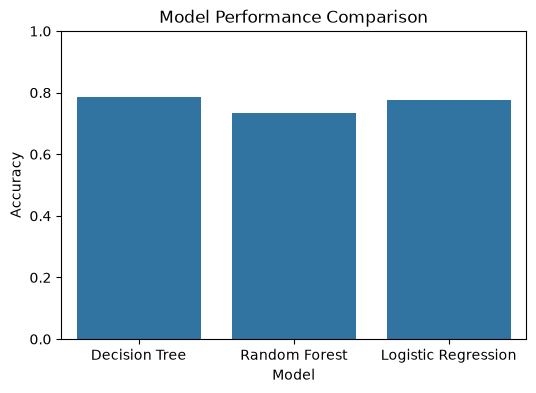

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Performance Comparison")
plt.ylim(0, 1)

plt.show()

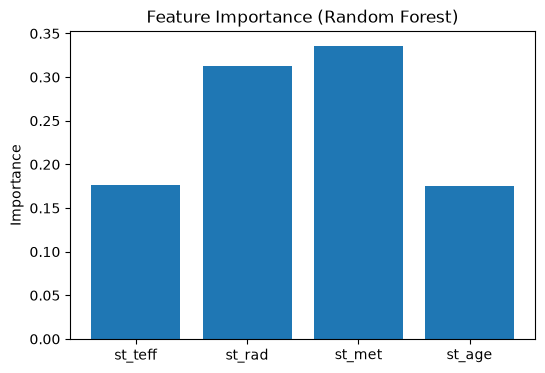

In [11]:
importances = rf_model.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(features, importances)

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")

plt.show()

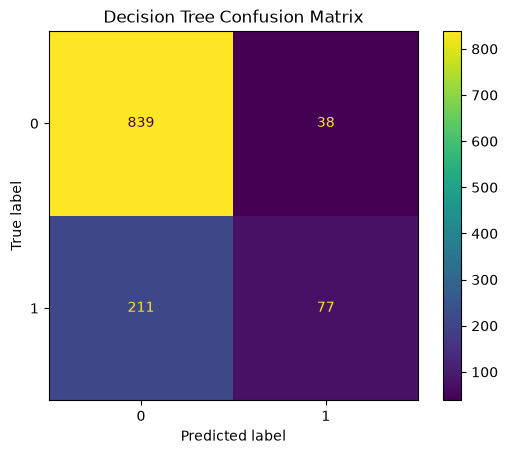

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

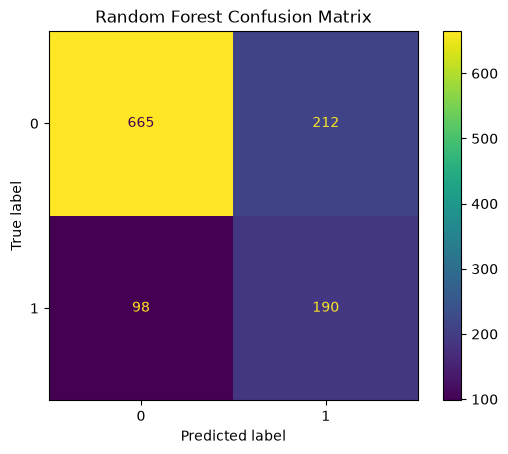

In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

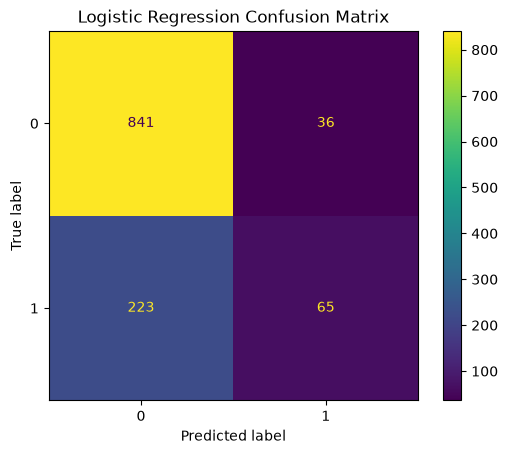

In [14]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import roc_curve, auc

In [16]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [17]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

In [18]:
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

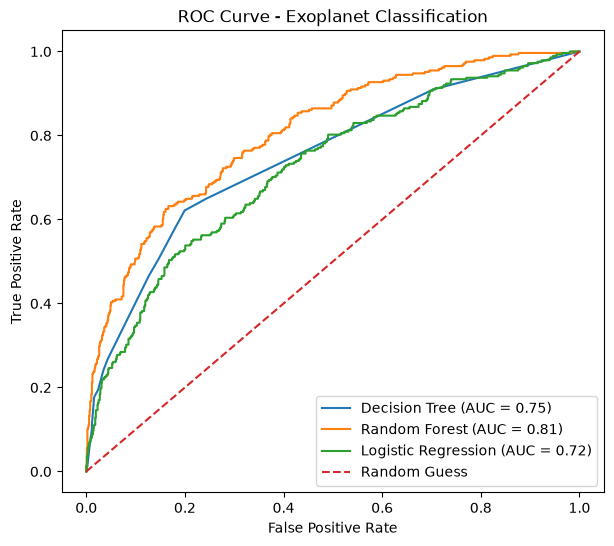

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Exoplanet Classification")
plt.legend()

plt.show()